# Predictive Maintenance: Scania APS Failure Detection

**Author**: Serhat Turan

**Date**: July 2026

## 1. Project Overview
The Air Pressure System (APS) in heavy Scania trucks generates pressurized air for critical functions like braking and gear changes. The goal of this project is to build a predictive maintenance machine learning pipeline that identifies APS failures from anonymized sensor telemetry before a breakdown occurs. 

## 2. The Data Challenge
This is a real-world industrial dataset with two significant data science challenges:
* **High Class Imbalance:** The training set contains 60,000 examples, but only 1,000 (1.6%) represent actual APS failures.
* **Missing & Anonymized Data:** The dataset contains 171 anonymized features (numerical counters and histogram bins) with significant missing values (`"na"`).

## 3. Business Evaluation Metric
Standard accuracy is a dangerous metric for this problem. Missing a faulty truck (False Negative) is significantly more expensive than unnecessarily checking a healthy truck (False Positive). 

The model will be evaluated on a custom cost metric to reflect real-world business impact as an example:
* **Cost_1 (False Positive):** 10 units (Cost of an unnecessary mechanic check)
* **Cost_2 (False Negative):** 500 units (Cost of a truck breaking down)
* **Total Cost = (10 × FP) + (500 × FN)**

The primary objective is to minimize this Total Cost.

In [1]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
import xgboost as xgb
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix

from lightgbm import LGBMClassifier

from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import make_scorer

# Set pandas to show all columns since we have 171 features
pd.set_option('display.max_columns', None)

DATA_DIR = Path('./data')

In [2]:
# First 20 lines are copyright information so we will do this:
aps_failure_training_set = pd.read_csv(
    DATA_DIR / 'aps_failure_training_set.csv', 
    na_values="na"
)

aps_failure_training_set.head(5)

,class,aa_000,ab_000,ac_000,ad_000,ae_000,af_000,ag_000,ag_001,ag_002,ag_003,ag_004,ag_005,ag_006,ag_007,ag_008,ag_009,ah_000,ai_000,aj_000,ak_000,al_000,am_0,an_000,ao_000,ap_000,aq_000,ar_000,as_000,at_000,au_000,av_000,ax_000,ay_000,ay_001,ay_002,ay_003,ay_004,ay_005,ay_006,ay_007,ay_008,ay_009,az_000,az_001,az_002,az_003,az_004,az_005,az_006,az_007,az_008,az_009,ba_000,ba_001,ba_002,ba_003,ba_004,ba_005,ba_006,ba_007,ba_008,ba_009,bb_000,bc_000,bd_000,be_000,bf_000,bg_000,bh_000,bi_000,bj_000,bk_000,bl_000,bm_000,bn_000,bo_000,bp_000,bq_000,br_000,bs_000,bt_000,bu_000,bv_000,bx_000,by_000,bz_000,ca_000,cb_000,cc_000,cd_000,ce_000,cf_000,cg_000,ch_000,ci_000,cj_000,ck_000,cl_000,cm_000,cn_000,cn_001,cn_002,cn_003,cn_004,cn_005,cn_006,cn_007,cn_008,cn_009,co_000,cp_000,cq_000,cr_000,cs_000,cs_001,cs_002,cs_003,cs_004,cs_005,cs_006,cs_007,cs_008,cs_009,ct_000,cu_000,cv_000,cx_000,cy_000,cz_000,da_000,db_000,dc_000,dd_000,de_000,df_000,dg_000,dh_000,di_000,dj_000,dk_000,dl_000,dm_000,dn_000,do_000,dp_000,dq_000,dr_000,ds_000,dt_000,du_000,dv_000,dx_000,dy_000,dz_000,ea_000,eb_000,ec_00,ed_000,ee_000,ee_001,ee_002,ee_003,ee_004,ee_005,ee_006,ee_007,ee_008,ee_009,ef_000,eg_000
0,neg,76698,NaN,2.130706e+09,280.0,0.0,0.0,0.0,0.0,0.0,0.0,37250.0,1432864.0,3664156.0,1007684.0,25896.0,0.0,2551696.0,0.0,0.0,0.0,0.0,0.0,4933296.0,3655166.0,1766008.0,1132040.0,0.0,0.0,0.0,0.0,1012.0,268.0,0.0,0.0,0.0,0.0,0.0,469014.0,4239660.0,703300.0,755876.0,0.0,5374.0,2108.0,4114.0,12348.0,615248.0,5526276.0,2378.0,4.0,0.0,0.0,2328746.0,1022304.0,415432.0,287230.0,310246.0,681504.0,1118814.0,3574.0,0.0,0.0,6700214.0,0.0,10.0,108.0,50.0,2551696.0,97518.0,947550.0,799478.0,330760.0,353400.0,299160.0,305200.0,283680.0,NaN,NaN,NaN,178540.0,76698.08,6700214.0,6700214.0,6599892.0,43566.0,68656.0,54064.0,638360.0,6167850.0,1209600.0,246244.0,2.0,96.0,0.0,5245752.00,0.0,916567.68,6.0,1924.0,0.0,0.0,0.0,118196.0,1309472.0,3247182.0,1381362.0,98822.0,11208.0,1608.0,220.0,240.0,6700214.0,NaN,10476.0,1226.0,267998.0,521832.0,428776.0,4015854.0,895240.0,26330.0,118.0,0.0,532.0,734.0,4122704.0,51288.0,0.0,532572.0,0.0,18.0,5330690.0,4732.0,1126.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,62282.0,85908.0,32790.0,0.0,0.0,202710.0,37928.0,14745580.0,1876644.0,0.0,0.0,0.0,0.0,2801180.0,2445.80,2712.0,965866.0,1706908.0,1240520.0,493384.0,721044.0,469792.0,339156.0,157956.0,73224.0,0.0,0.0,0.0
1,neg,33058,NaN,0.000000e+00,NaN,0.0,0.0,0.0,0.0,0.0,0.0,18254.0,653294.0,1720800.0,516724.0,31642.0,0.0,1393352.0,0.0,68.0,0.0,0.0,0.0,2560898.0,2127150.0,1084598.0,338544.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,71510.0,772720.0,1996924.0,99560.0,0.0,7336.0,7808.0,13776.0,13086.0,1010074.0,1873902.0,14726.0,6.0,0.0,0.0,1378576.0,447166.0,199512.0,154298.0,137280.0,138668.0,165908.0,229652.0,87082.0,4708.0,3646660.0,86.0,454.0,364.0,350.0,1393352.0,49028.0,688314.0,392208.0,341420.0,359780.0,366560.0,NaN,NaN,NaN,NaN,NaN,6700.0,33057.51,3646660.0,3646660.0,3582034.0,17733.0,260120.0,115626.0,6900.0,2942850.0,1209600.0,0.0,NaN,NaN,NaN,2291079.36,0.0,643536.96,0.0,0.0,0.0,0.0,38.0,98644.0,1179502.0,1286736.0,336388.0,36294.0,5192.0,56.0,NaN,0.0,3646660.0,NaN,6160.0,796.0,164860.0,350066.0,272956.0,1837600.0,301242.0,9148.0,22.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3312.0,522.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,33736.0,36946.0,5936.0,0.0,0.0,103330.0,16254.0,4510080.0,868538.0,0.0,0.0,0.0,0.0,3477820.0,2211.76,2334.0,664504.0,824154.0,421400.0,178064.0,293306.0,245416.0,133654.0,81140.0,97576.0,1500.0,0.0,0.0
2,neg,41040,NaN,2.280000e+02,100.0,0.0,0.0,0.0,0.0,0.0,0.0,1648.0,370592.0,1883374.0,292936.0,12016.0,0.0,1234132.0,0.0,0.0,0.0,0.0,0.0,2371990.0,2173634.0,300796.0,153698.0,0.0,0.0,0.0,0.0,358.0,110.0,0.0,0.0,0.0,0.0,0.0,0.0,870456.0,239798.0,1450312.0,0.0,1620.0,1156.0,1228.0,34250.0,1811606.0,710672.0,34.0,0.0,0.0,0.0,790690.0,672026.0,332340.0,254892.0,189596.0,135758.0,103552.0,81666.0,46.0,0.0,2673338.0,128.0,202.0,576.0,4.0,1234132.0,28804.0,160176.0,139730.0,137160.0,13064

In [3]:
aps_failure_training_set.info()

<class 'pandas.DataFrame'>
RangeIndex: 60000 entries, 0 to 59999
Columns: 171 entries, class to eg_000
dtypes: float64(169), int64(1), str(1)
memory usage: 78.3 MB


In [4]:
# Let's calculate the missing data
missing_data = aps_failure_training_set.isnull().sum() / len(aps_failure_training_set) * 100

missing_data.sort_values(ascending = False, inplace = True)
print(missing_data.head(20))

br_000    82.106667
bq_000    81.203333
bp_000    79.566667
bo_000    77.221667
ab_000    77.215000
cr_000    77.215000
bn_000    73.348333
bm_000    65.915000
bl_000    45.461667
bk_000    38.390000
ad_000    24.768333
cg_000    24.768333
ch_000    24.768333
cf_000    24.768333
co_000    24.768333
cx_000    23.013333
cz_000    23.013333
cy_000    23.013333
dc_000    23.013333
db_000    23.013333
dtype: float64


In [5]:
# We are going to get rid of columns with a lot of missing data
threshold = 60
columns_to_drop = missing_data[missing_data > threshold].index

df_cleaned = aps_failure_training_set.drop(columns=columns_to_drop)

print(f"Dropped {len(columns_to_drop)} columns.")
print(f"Remaining columns: {df_cleaned.shape[1]}")

Dropped 8 columns.
Remaining columns: 163


In [6]:
# Check the exact ratio of positive (failure) vs negative (healthy) cases
print(df_cleaned['class'].value_counts())
print("\nPercentage split:")
print(df_cleaned['class'].value_counts(normalize=True) * 100)

class
neg    59000
pos     1000
Name: count, dtype: int64

Percentage split:
class
neg    98.333333
pos     1.666667
Name: proportion, dtype: float64


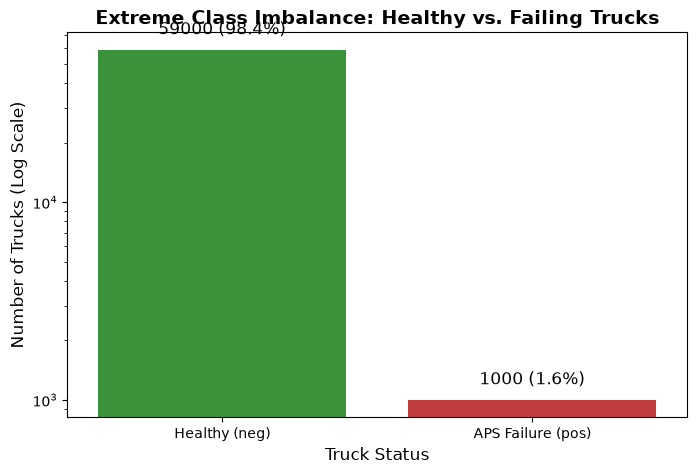

In [7]:
# Visualize the extreme class imbalance
plt.figure(figsize=(8, 5))

# Using a logarithmic scale so the tiny failure class is actually visible
sns.countplot(data=df_cleaned, x='class', hue='class', palette=['#2ca02c', '#d62728'], legend=False)

plt.title('Extreme Class Imbalance: Healthy vs. Failing Trucks', fontsize=14, fontweight='bold')
plt.xlabel('Truck Status', fontsize=12)
plt.ylabel('Number of Trucks (Log Scale)', fontsize=12)
plt.yscale('log')
plt.xticks(ticks=[0, 1], labels=['Healthy (neg)', 'APS Failure (pos)'])

# Add text annotations
counts = df_cleaned['class'].value_counts()

# Using the explicit labels 'neg' and 'pos' to avoid indexing errors
plt.text(0, counts['neg']*1.2, f"{counts['neg']} (98.4%)", ha='center', fontsize=12)
plt.text(1, counts['pos']*1.2, f"{counts['pos']} (1.6%)", ha='center', fontsize=12)

plt.show()

In [8]:
X = df_cleaned.drop(columns=['class'])
y = df_cleaned['class']

# Building a dictionary of different imputation strategies
imputation_strategies = {
    'median': SimpleImputer(strategy='median'),
    'mean': SimpleImputer(strategy='mean'),
    'most_frequent': SimpleImputer(strategy='most_frequent')
}

# Empty dictionary to hold the new DataFrames
X_imputed = {}

# Loop through each strategy and apply it
for name, imputer in imputation_strategies.items():
    print(f"Applying {name} imputation...")
    
    # SimpleImputer outputs a raw NumPy array, stripping column names
    imputed_array = imputer.fit_transform(X)
    
    # Convert it back into a pandas DataFrame so I don't lose the sensor names
    X_imputed[name] = pd.DataFrame(imputed_array, columns=X.columns)

print("Success")

Applying median imputation...
Applying mean imputation...
Applying most_frequent imputation...
Success


In [9]:
X_imputed['median'].head()
# This way we will be able to test different strategies for the best results

,aa_000,ac_000,ad_000,ae_000,af_000,ag_000,ag_001,ag_002,ag_003,ag_004,ag_005,ag_006,ag_007,ag_008,ag_009,ah_000,ai_000,aj_000,ak_000,al_000,am_0,an_000,ao_000,ap_000,aq_000,ar_000,as_000,at_000,au_000,av_000,ax_000,ay_000,ay_001,ay_002,ay_003,ay_004,ay_005,ay_006,ay_007,ay_008,ay_009,az_000,az_001,az_002,az_003,az_004,az_005,az_006,az_007,az_008,az_009,ba_000,ba_001,ba_002,ba_003,ba_004,ba_005,ba_006,ba_007,ba_008,ba_009,bb_000,bc_000,bd_000,be_000,bf_000,bg_000,bh_000,bi_000,bj_000,bk_000,bl_000,bs_000,bt_000,bu_000,bv_000,bx_000,by_000,bz_000,ca_000,cb_000,cc_000,cd_000,ce_000,cf_000,cg_000,ch_000,ci_000,cj_000,ck_000,cl_000,cm_000,cn_000,cn_001,cn_002,cn_003,cn_004,cn_005,cn_006,cn_007,cn_008,cn_009,co_000,cp_000,cq_000,cs_000,cs_001,cs_002,cs_003,cs_004,cs_005,cs_006,cs_007,cs_008,cs_009,ct_000,cu_000,cv_000,cx_000,cy_000,cz_000,da_000,db_000,dc_000,dd_000,de_000,df_000,dg_000,dh_000,di_000,dj_000,dk_000,dl_000,dm_000,dn_000,do_000,dp_000,dq_000,dr_000,ds_000,dt_000,du_000,dv_000,dx_000,dy_000,dz_000,ea_000,eb_000,ec_00,ed_000,ee_000,ee_001,ee_002,ee_003,ee_004,ee_005,ee_006,ee_007,ee_008,ee_009,ef_000,eg_000
0,76698.0,2.130706e+09,280.0,0.0,0.0,0.0,0.0,0.0,0.0,37250.0,1432864.0,3664156.0,1007684.0,25896.0,0.0,2551696.0,0.0,0.0,0.0,0.0,0.0,4933296.0,3655166.0,1766008.0,1132040.0,0.0,0.0,0.0,0.0,1012.0,268.0,0.0,0.0,0.0,0.0,0.0,469014.0,4239660.0,703300.0,755876.0,0.0,5374.0,2108.0,4114.0,12348.0,615248.0,5526276.0,2378.0,4.0,0.0,0.0,2328746.0,1022304.0,415432.0,287230.0,310246.0,681504.0,1118814.0,3574.0,0.0,0.0,6700214.0,0.0,10.0,108.0,50.0,2551696.0,97518.0,947550.0,799478.0,330760.0,353400.0,178540.0,76698.08,6700214.0,6700214.0,6599892.0,43566.0,68656.0,54064.0,638360.0,6167850.0,1209600.0,246244.0,2.0,96.0,0.0,5245752.00,0.0,916567.68,6.0,1924.0,0.0,0.0,0.0,118196.0,1309472.0,3247182.0,1381362.0,98822.0,11208.0,1608.0,220.0,240.0,6700214.0,10476.0,1226.0,267998.0,521832.0,428776.0,4015854.0,895240.0,26330.0,118.0,0.0,532.0,734.0,4122704.0,51288.0,0.0,532572.0,0.0,18.0,5330690.0,4732.0,1126.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,62282.0,85908.0,32790.0,0.0,0.0,202710.0,37928.0,14745580.0,1876644.0,0.0,0.0,0.0,0.0,2801180.0,2445.80,2712.0,965866.0,1706908.0,1240520.0,493384.0,721044.0,469792.0,339156.0,157956.0,73224.0,0.0,0.0,0.0
1,33058.0,0.000000e+00,126.0,0.0,0.0,0.0,0.0,0.0,0.0,18254.0,653294.0,1720800.0,516724.0,31642.0,0.0,1393352.0,0.0,68.0,0.0,0.0,0.0,2560898.0,2127150.0,1084598.0,338544.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,71510.0,772720.0,1996924.0,99560.0,0.0,7336.0,7808.0,13776.0,13086.0,1010074.0,1873902.0,14726.0,6.0,0.0,0.0,1378576.0,447166.0,199512.0,154298.0,137280.0,138668.0,165908.0,229652.0,87082.0,4708.0,3646660.0,86.0,454.0,364.0,350.0,1393352.0,49028.0,688314.0,392208.0,341420.0,359780.0,6700.0,33057.51,3646660.0,3646660.0,3582034.0,17733.0,260120.0,115626.0,6900.0,2942850.0,1209600.0,0.0,2.0,46.0,0.0,2291079.36,0.0,643536.96,0.0,0.0,0.0,0.0,38.0,98644.0,1179502.0,1286736.0,336388.0,36294.0,5192.0,56.0,8.0,0.0,3646660.0,6160.0,796.0,164860.0,350066.0,272956.0,1837600.0,301242.0,9148.0,22.0,0.0,210.0,278.0,1181117.0,44465.0,0.0,202.0,0.0,0.0,1734472.0,3312.0,522.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,33736.0,36946.0,5936.0,0.0,0.0,103330.0,16254.0,4510080.0,868538.0,0.0,0.0,0.0,0.0,3477820.0,2211.76,2334.0,664504.0,824154.0,421400.0,178064.0,293306.0,245416.0,133654.0,81140.0,97576.0,1500.0,0.0,0.0
2,41040.0,2.280000e+02,100.0,0.0,0.0,0.0,0.0,0.0,0.0,1648.0,370592.0,1883374.0,292936.0,12016.0,0.0,1234132.0,0.0,0.0,0.0,0.0,0.0,2371990.0,2173634.0,300796.0,153698.0,0.0,0.0,0.0,0.0,358.0,110.0,0.0,0.0,0.0,0.0,0.0,0.0,870456.0,239798.0,1450312.0,0.0,1620.0,1156.0,1228.0,34250.0,1811606.0,710672.0,34.0,0.0,0.0,0.0,790690.0,672026.0,332340.0,254892.0,189596.0,135758.0,103552.0,81666.0,46.0,0.0,2673338.0,128.0,202.0,576.0,4.0,1234132.0,28804.0,160176.0,139730.0,137160.0,130640.0,28000.0,41040.08,2673338.0,2673338.0,2678534.0,15439.0,7466.0,22436.0,248240.0,2560566.0,1209600.0,63328.0,0.0,124.0,0.0,232269

In [10]:
X_baseline = X_imputed["median"]

X_train, X_test, y_train, y_test = train_test_split(
    X_baseline, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training features shape: {X_train.shape}")
print(f"Testing features shape: {X_test.shape}")

Training features shape: (48000, 162)
Testing features shape: (12000, 162)


In [11]:
def scania_cost_metric(y_true, y_pred):
    """
    Calculates the custom cost metric for the APS Failure dataset.
    False Positive (Cost_1) = 10
    False Negative (Cost_2) = 500
    """
    # Create a confusion matrix
    # Extract True Negatives, False Positives, False Negatives, True Positives
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=['neg', 'pos']).ravel()
    
    # Calculate the total cost
    total_cost = (10 * fp) + (500 * fn)
    
    return total_cost

In [12]:
# XGBoost requires the target variable to be numerical (0 and 1) instead of text
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

# Calculate the imbalance weight for XGBoost
# 59000 negatives / 1000 positives = 59
imbalance_weight = 59 

# Initialize the model
xgb_model = XGBClassifier(
    scale_pos_weight=imbalance_weight,
    random_state=42,
    eval_metric='logloss'
)

print("Training XGBoost baseline")
xgb_model.fit(X_train, y_train_encoded)
print("Training complete!")

Training XGBoost baseline
Training complete!


 Total Scania Cost Penalty: 18050


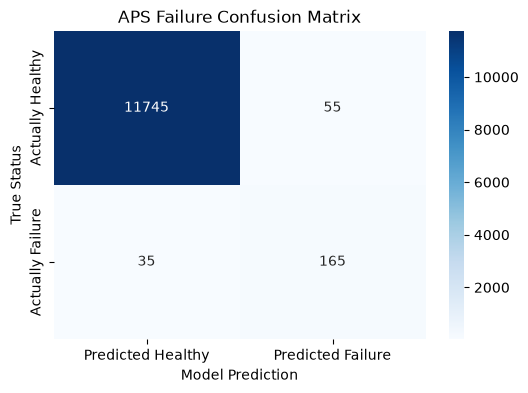

In [13]:
y_pred_encoded = xgb_model.predict(X_test)

# 2. Translate the predictions (0s and 1s) back to 'neg' and 'pos' 
# We do this because our scania_cost_metric function expects the original text labels
y_pred = le.inverse_transform(y_pred_encoded)

# Calculate the total financial penalty 
# Compare the ground truth (y_test) against the model's guesses (y_pred)
total_penalty = scania_cost_metric(y_test, y_pred)
print(f" Total Scania Cost Penalty: {total_penalty}")

# Visualize the Confusion Matrix to see the exact mistakes
cm = confusion_matrix(y_test, y_pred, labels=['neg', 'pos'])

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Predicted Healthy', 'Predicted Failure'], 
            yticklabels=['Actually Healthy', 'Actually Failure'])
plt.title('APS Failure Confusion Matrix')
plt.ylabel('True Status')
plt.xlabel('Model Prediction')
plt.show()

In [14]:
from sklearn.pipeline import Pipeline

#  Define Features and Target
X = df_cleaned.drop(columns=['class'])
y = df_cleaned['class']

# Encode the target ('neg' -> 0, 'pos' -> 1)
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# 2. Train-Test Split FIRST so data doesn't leak
X_train, X_test, y_train_encoded, y_test_encoded = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

# Here is the Leak-Proof Pipeline
imbalance_weight = 59 
production_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('classifier', XGBClassifier(scale_pos_weight=imbalance_weight, random_state=42, eval_metric='logloss'))
])

# The pipeline automatically fits the imputer ONLY on X_train, then trains XGBoost here
print("Training Pipeline...")
production_pipeline.fit(X_train, y_train_encoded)

# The pipeline automatically applies the trained imputer to X_test before predicting
y_pred_encoded = production_pipeline.predict(X_test)

# Reverse the encoding to calculate custom cost
y_pred = le.inverse_transform(y_pred_encoded)
y_test_original = le.inverse_transform(y_test_encoded)

final_cost = scania_cost_metric(y_test_original, y_pred)
print(f" Training complete. Final Cost Penalty: {final_cost}")

Training Pipeline...
 Training complete. Final Cost Penalty: 17480


In [15]:
# features (X) and target (y)
X = df_cleaned.drop(columns=['class'])
y = df_cleaned['class']

#  Train-Test Split first here so no data leakage
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 2. Fit the imputer after only on the training data
print("Applying most_frequent imputation...")
imputer = SimpleImputer(strategy='most_frequent')

X_train_imputed = pd.DataFrame(imputer.fit_transform(X_train), columns=X_train.columns)

# Transform the testing data using the statistics learned from the training data
X_test_imputed = pd.DataFrame(imputer.transform(X_test), columns=X_test.columns)

# Encoding the target (neg -> 0, pos -> 1)
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

# Training the final XGBoost Model
print("Training XGBoost model...")
imbalance_weight = 59 
xgb_final = XGBClassifier(
    scale_pos_weight=imbalance_weight,
    random_state=42,
    eval_metric='logloss'
)
xgb_final.fit(X_train_imputed, y_train_encoded)

# Evaluate the final model
y_pred_encoded = xgb_final.predict(X_test_imputed)
y_pred = le.inverse_transform(y_pred_encoded)
final_cost = scania_cost_metric(y_test, y_pred)

print(f" Training complete. Final Cost Penalty: {final_cost}")

Applying most_frequent imputation...
Training XGBoost model...
 Training complete. Final Cost Penalty: 17480


# Now that we have a basic model I will focus on improving it

In [16]:
# Extract feature importances from your trained xgb_final model
importances = xgb_final.feature_importances_

# Create a DataFrame and sort it by how important the model found them
feature_importance_df = pd.DataFrame({
    'Feature': X_train.columns, 
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Select the top 75 features
top_75_features = feature_importance_df['Feature'].head(75).tolist()

# Create new datasets using ONLY these 75 columns
X_train_top = X_train[top_75_features]
X_test_top = X_test[top_75_features]

print(f"Data reduced from {X_train.shape[1]} down to {X_train_top.shape[1]} features.")

Data reduced from 162 down to 75 features.


C:\Users\serha\AppData\Local\Temp\ipykernel_14044\626785954.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


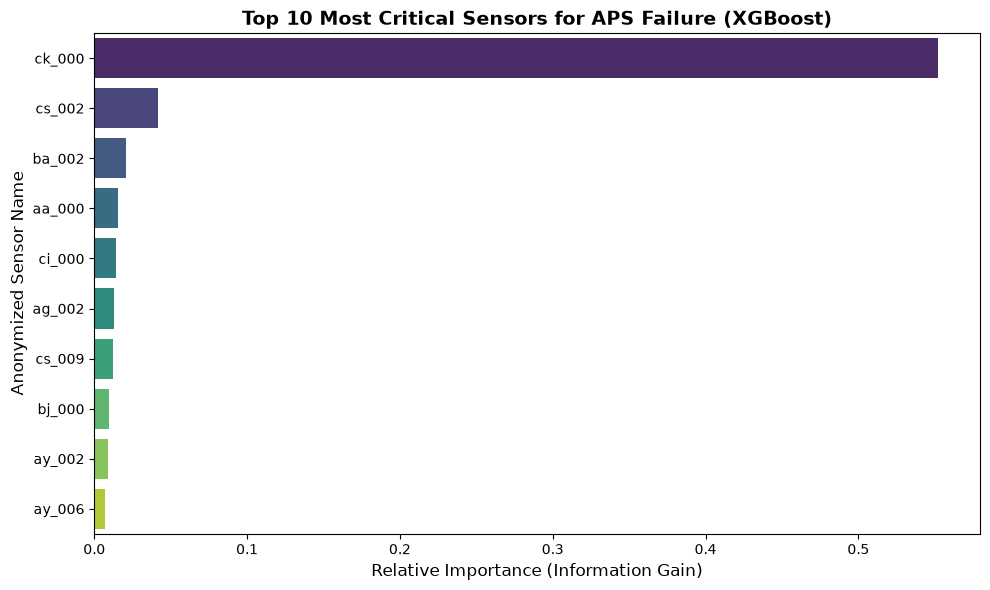

In [17]:
# Visualize the Top 10 Most Critical Sensors
plt.figure(figsize=(10, 6))
sns.barplot(
    x='Importance', 
    y='Feature', 
    data=feature_importance_df.head(10), 
    palette='viridis'
)
plt.title('Top 10 Most Critical Sensors for APS Failure (XGBoost)', fontsize=14, fontweight='bold')
plt.xlabel('Relative Importance (Information Gain)', fontsize=12)
plt.ylabel('Anonymized Sensor Name', fontsize=12)
plt.tight_layout()
plt.show()

In [18]:
# Initialize LightGBM with the same 59x imbalance weight
lgb_model = LGBMClassifier(
    scale_pos_weight=imbalance_weight,
    random_state=42,
    n_estimators=100
)

print("Training LightGBM on the Top 75 features")
lgb_model.fit(X_train_top, y_train_encoded)

# Predict and evaluate
y_pred_lgb_encoded = lgb_model.predict(X_test_top)
y_pred_lgb = le.inverse_transform(y_pred_lgb_encoded)

lgb_cost = scania_cost_metric(y_test, y_pred_lgb)
print(f"LightGBM Baseline Cost: {lgb_cost}")

Training LightGBM on the Top 75 features
[LightGBM] [Info] Number of positive: 800, number of negative: 47200
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.015633 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 18297
[LightGBM] [Info] Number of data points in the train set: 48000, number of used features: 75
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.016667 -> initscore=-4.077537
[LightGBM] [Info] Start training from score -4.077537
LightGBM Baseline Cost: 11810


In [19]:
# By default, LightGBM predicts a breakdown only if it is >50% sure. 
# We are going to loop through every threshold from 1% up to 50%
# predict_proba returns the raw percentage certainty, not just a 0 or 1
# [:, 1] grabs the probability specifically for the 'pos' (failure) class
y_probabilities = lgb_model.predict_proba(X_test_top)[:, 1]

best_cost = float('inf')
best_threshold = 0.5

print("Testing all thresholds from 1% to 50%...\n")

for thresh in np.arange(0.01, 0.51, 0.01):
    # If the probability is above our custom threshold, flag it as a 1 (failure)
    y_pred_thresh_encoded = (y_probabilities >= thresh).astype(int)
    
    # Translate back to 'neg' and 'pos' to calculate the custom cost
    y_pred_thresh = le.inverse_transform(y_pred_thresh_encoded)
    current_cost = scania_cost_metric(y_test, y_pred_thresh)
    
    # Save the best score
    if current_cost < best_cost:
        best_cost = current_cost
        best_threshold = thresh

print(f" Optimal Threshold found at: {best_threshold * 100:.0f}%")
print(f" New Lowest Total Penalty: {best_cost}")

Testing all thresholds from 1% to 50%...

 Optimal Threshold found at: 16%
 New Lowest Total Penalty: 7760


In [20]:
# Convert our custom cost function into a scikit-learn scorer
# greater_is_better=False because we want the LOWEST penalty
scania_scorer = make_scorer(scania_cost_metric, greater_is_better=False)

# Define the hyperparameters we want the computer to test
param_distributions = {
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [3, 5, 7, -1],
    'num_leaves': [15, 31, 63],
    'subsample': [0.8, 1.0]
}

print("Starting Randomized Search (this may take a few minutes)")
random_search = RandomizedSearchCV(
    estimator=LGBMClassifier(scale_pos_weight=imbalance_weight, random_state=42),
    param_distributions=param_distributions,
    n_iter=10, # Tests 10 random combinations
    scoring=scania_scorer,
    cv=3, # 3-fold cross validation
    random_state=42,
    n_jobs=-1 # Uses all of the CPU cores I have
)

random_search.fit(X_train_top, y_train)

print("\nBest Parameters found:")
print(random_search.best_params_)

Starting Randomized Search (this may take a few minutes)
[LightGBM] [Info] Number of positive: 800, number of negative: 47200
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.016597 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 18297
[LightGBM] [Info] Number of data points in the train set: 48000, number of used features: 75
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.016667 -> initscore=-4.077537
[LightGBM] [Info] Start training from score -4.077537

Best Parameters found:
{'subsample': 0.8, 'num_leaves': 15, 'max_depth': -1, 'learning_rate': 0.05}


In [21]:
# Our best model here:
lgb_final = LGBMClassifier(
    scale_pos_weight=imbalance_weight,
    random_state=42,
    n_estimators=100,
    subsample=0.8, 
    num_leaves=15, 
    max_depth=-1, 
    learning_rate=0.05
)

print("Training the Final Tuned LightGBM model...")
lgb_final.fit(X_train_top, y_train_encoded)

# Extract probabilities from the newly tuned model
y_probabilities_final = lgb_final.predict_proba(X_test_top)[:, 1]

best_cost_final = float('inf')
best_threshold_final = 0.5

# Run the threshold optimizer one last time
print("Optimizing threshold for the tuned model...\n")
for thresh in np.arange(0.01, 0.51, 0.01):
    y_pred_thresh_encoded = (y_probabilities_final >= thresh).astype(int)
    y_pred_thresh = le.inverse_transform(y_pred_thresh_encoded)
    
    current_cost = scania_cost_metric(y_test, y_pred_thresh)
    
    if current_cost < best_cost_final:
        best_cost_final = current_cost
        best_threshold_final = thresh

print(f" Final Tuned Optimal Threshold: {best_threshold_final * 100:.0f}%")
print(f" Ultimate Lowest Total Penalty: {best_cost_final}")

Training the Final Tuned LightGBM model...
[LightGBM] [Info] Number of positive: 800, number of negative: 47200
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.015789 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 18297
[LightGBM] [Info] Number of data points in the train set: 48000, number of used features: 75
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.016667 -> initscore=-4.077537
[LightGBM] [Info] Start training from score -4.077537
Optimizing threshold for the tuned model...

 Final Tuned Optimal Threshold: 50%
 Ultimate Lowest Total Penalty: 7280


# Thoughts
We went down from 17910 to 7280. In real life this would save a company millions of dollars.
I am happy with the result so now I will test it with the test file I have.
This will also help me understand if there was any leakage.

In [22]:
def evaluate_production_model(csv_path, model, imputer, base_columns, model_features, threshold, label_encoder):
    """
    Loads raw test data, applies the pre-fitted preprocessing pipeline, 
    and evaluates the model using the custom Scania cost metric.
    """
    print(f"Loading unseen test data from: {csv_path}")
    
    # Load the raw test dataset (
    df_test = pd.read_csv(csv_path, na_values="na")
    
    # Separate features and target
    X_test_raw = df_test.drop(columns=['class'])
    y_test_raw = df_test['class']
    
    # Align with the original training columns
    X_test_aligned = X_test_raw[base_columns]
    
    # Impute using the already fitted imputer (to prevent data leakage)
    X_test_imputed = pd.DataFrame(
        imputer.transform(X_test_aligned), 
        columns=base_columns
    )
    
    #  Filter down to the specific features this model needs (162 vs 75)
    X_test_final = X_test_imputed[model_features]
    
    #  Encode the target variable
    y_test_encoded = label_encoder.transform(y_test_raw)
    
    # Generate probabilities and apply the custom threshold
    y_probabilities = model.predict_proba(X_test_final)[:, 1]
    y_pred_thresh_encoded = (y_probabilities >= threshold).astype(int)
    
    # Translate back to 'neg' and 'pos' and calculate the cost
    y_pred_thresh = label_encoder.inverse_transform(y_pred_thresh_encoded)
    tn, fp, fn, tp = confusion_matrix(y_test_raw, y_pred_thresh, labels=['neg', 'pos']).ravel()
    
    total_cost = (10 * fp) + (500 * fn)
    
    print("-" * 40)
    print("Model Evaluation Results")
    print("-" * 40)
    print(f"False Positives (Cost: 10)  : {fp}")
    print(f"False Negatives (Cost: 500) : {fn}")
    print(f" Final Test Set Penalty   : {total_cost}")
    print("-" * 40, "\n")
    
    return total_cost

In [23]:
TEST_FILE_PATH = DATA_DIR / 'aps_failure_test_set.csv'

# Make sure we have the exact column list the imputer was trained on
base_162_columns = X.columns.tolist()

# Test 1: The Baseline XGBoost 
print(">>> Testing Baseline XGBoost Model (162 Features, 50% default threshold)")
xgb_test_cost = evaluate_production_model(
    csv_path=TEST_FILE_PATH,
    model=xgb_final,
    imputer=imputer,
    base_columns=base_162_columns,
    model_features=base_162_columns, # XGBoost uses all 162
    threshold=0.50, # Standard default threshold
    label_encoder=le
)

#  TEST 2: The Tuned LightGBM 
print(">>> Testing Tuned LightGBM Model (75 Features, 30% optimized threshold)")
lgb_test_cost = evaluate_production_model(
    csv_path=TEST_FILE_PATH,
    model=lgb_final,  
    imputer=imputer,
    base_columns=base_162_columns,
    model_features=top_75_features, # LightGBM only uses the top 75
    threshold=0.30, # The discovered optimal threshold
    label_encoder=le
)

>>> Testing Baseline XGBoost Model (162 Features, 50% default threshold)
Loading unseen test data from: data\aps_failure_test_set.csv
----------------------------------------
Model Evaluation Results
----------------------------------------
False Positives (Cost: 10)  : 44
False Negatives (Cost: 500) : 58
 Final Test Set Penalty   : 29440
---------------------------------------- 

>>> Testing Tuned LightGBM Model (75 Features, 30% optimized threshold)
Loading unseen test data from: data\aps_failure_test_set.csv
----------------------------------------
Model Evaluation Results
----------------------------------------
False Positives (Cost: 10)  : 550
False Negatives (Cost: 500) : 17
 Final Test Set Penalty   : 14000
---------------------------------------- 



In [24]:
import joblib
import os

# Create a folder called 'models' in your project directory
os.makedirs('models', exist_ok=True)

# Package all the critical pipeline components together
pipeline_artifacts = {
    'model': lgb_final,
    'imputer': imputer,
    'label_encoder': le,
    'features': top_75_features,
    'optimal_threshold': 0.30
}

# Export the package to a compressed file
export_path = 'models/scania_lgbm_pipeline.pkl'
joblib.dump(pipeline_artifacts, export_path)

print(f" Production pipeline successfully exported to {export_path}")

 Production pipeline successfully exported to models/scania_lgbm_pipeline.pkl
